<a href="https://colab.research.google.com/github/GOE84/Financial-Market-Analysis/blob/main/market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **โครงการวิเคราะห์ราคาหุ้น**

สมุดบันทึกนี้มีวัตถุประสงค์เพื่อดึงข้อมูลราคาหุ้นจาก Yahoo Finance, ทำความสะอาดข้อมูลเบื้องต้น, บันทึกข้อมูลลงในไฟล์ CSV และแสดงผลเป็นกราฟ


#### 1. **นำเข้าไลบรารีที่จำเป็น**

เซลล์นี้จะนำเข้าไลบรารี Python ที่เราจะใช้ตลอดทั้งโครงการ:
- `yfinance`: สำหรับดาวน์โหลดข้อมูลหุ้นจาก Yahoo Finance
- `pandas`: สำหรับจัดการและวิเคราะห์ข้อมูลในรูปแบบ DataFrame
- `matplotlib.pyplot`: สำหรับสร้างกราฟและแสดงผลข้อมูล
- `os`: สำหรับจัดการระบบไฟล์ เช่น การสร้างไดเรกทอรี


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os

#### 2. **กำหนดพารามิเตอร์**

เซลล์นี้ใช้สำหรับกำหนดตัวแปรหลักๆ ที่จะใช้ในการดึงข้อมูลหุ้น รวมถึง:
- `TICKER`: สัญลักษณ์หุ้นที่ต้องการ (เช่น 'AAPL' สำหรับ Apple)
- `START_DATE`: วันที่เริ่มต้นสำหรับการดึงข้อมูล
- `END_DATE`: วันที่สิ้นสุดสำหรับการดึงข้อมูล
- `RAW_DATA_PATH`: ตำแหน่งและชื่อไฟล์ที่จะบันทึกข้อมูลดิบ


In [ ]:
TICKER = 'AAPL'  # เปลี่ยนเป็นหุ้นที่อยากได้ เช่น 'TSLA', 'BTC-USD', 'PTT.BK'
START_DATE = '2015-01-01'
END_DATE = '2024-01-01'
RAW_DATA_PATH = '../data/raw/stock_price.csv' # เซฟย้อนกลับไปที่โฟลเดอร์ data/raw

#### 3. **ดาวน์โหลดข้อมูลราคาหุ้น**

เซลล์นี้ใช้ไลบรารี `yfinance` เพื่อดึงข้อมูลราคาหุ้นของ `TICKER` ที่ระบุในช่วง `START_DATE` ถึง `END_DATE` ข้อมูลที่ได้จะถูกเก็บไว้ใน DataFrame ชื่อ `df`.


In [ ]:
# 1. โหลดข้อมูลจาก Yahoo Finance
print(f"กำลังดึงข้อมูลหุ้น {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

/tmp/ipython-input-1128716513.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

กำลังดึงข้อมูลหุ้น AAPL...


#### 4. **ตรวจสอบข้อมูลเบื้องต้น (5 แถวแรก)**

หลังจากดาวน์โหลดข้อมูลแล้ว เซลล์นี้จะแสดง 5 แถวแรกของ DataFrame `df` เพื่อให้เห็นโครงสร้างและหน้าตาของข้อมูลที่ดึงมาได้


In [ ]:
# 2. ดูหน้าตาข้อมูล 5 แถวแรก
print("\n--- ตัวอย่างข้อมูล ---")
print(df.head())


--- ตัวอย่างข้อมูล ---
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.237555  24.705324  23.798604  24.694239  212818400
2015-01-05  23.554739  24.086799  23.368519  24.006990  257142000
2015-01-06  23.556957  23.816336  23.195599  23.619031  263188400
2015-01-07  23.887272  23.987032  23.654495  23.765341  160423600
2015-01-08  24.805082  24.862723  24.097885  24.215383  237458000


#### 5. **ตรวจสอบค่าที่หายไป (Missing Values)**

เซลล์นี้จะตรวจสอบว่ามีข้อมูลใดใน DataFrame ที่เป็นค่าว่าง (`NaN`) หรือไม่ โดยจะแสดงผลรวมของค่าว่างในแต่ละคอลัมน์ เพื่อให้เราทราบถึงคุณภาพของข้อมูล.


In [ ]:
# 3. เช็คว่ามีข้อมูลหายไหม (Missing Values)
print("\n--- เช็คค่าว่าง ---")
print(df.isnull().sum())


--- เช็คค่าว่าง ---
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


#### 6. **บันทึกข้อมูลลงไฟล์ CSV**

เซลล์นี้จะสร้างไดเรกทอรีที่จำเป็น (ถ้ายังไม่มี) และบันทึก DataFrame `df` ลงในไฟล์ CSV ตามที่ระบุใน `RAW_DATA_PATH` การบันทึกข้อมูลดิบช่วยให้สามารถนำกลับมาใช้ใหม่ได้โดยไม่ต้องดาวน์โหลดซ้ำ


In [ ]:
# 4. บันทึกเป็นไฟล์ CSV เก็บไว้
# (เช็ค path ให้ชัวร์ก่อนเซฟ)
os.makedirs(os.path.dirname(RAW_DATA_PATH), exist_ok=True)
df.to_csv(RAW_DATA_PATH)
print(f"\nบันทึกไฟล์เรียบร้อยที่: {RAW_DATA_PATH}")


บันทึกไฟล์เรียบร้อยที่: ../data/raw/stock_price.csv


#### 7. **พล็อตกราฟราคาปิดของหุ้น**

เซลล์สุดท้ายนี้จะสร้างกราฟเส้นแสดงราคาปิด (`Close` price) ของหุ้น `TICKER` ตลอดช่วงเวลาที่กำหนด `(START_DATE - END_DATE)` เพื่อให้เห็นแนวโน้มของราคาหุ้นได้อย่างชัดเจน.


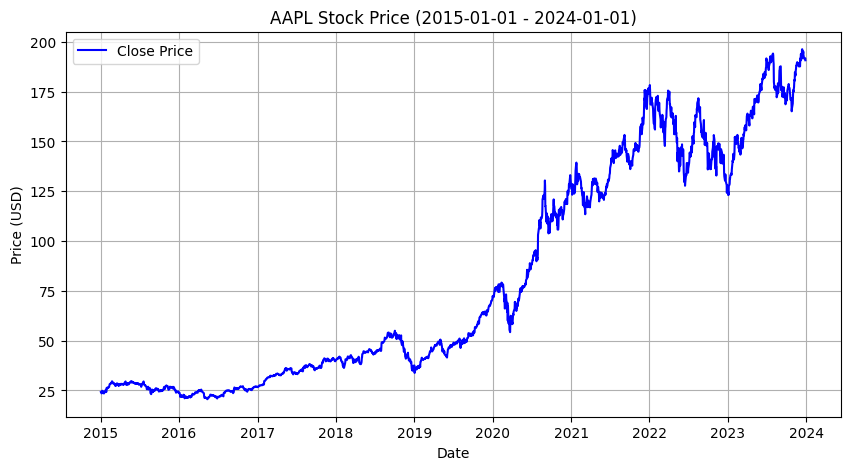

In [ ]:
# 5. พล็อตกราฟราคาปิดดูทรง
plt.figure(figsize=(10, 5))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title(f'{TICKER} Stock Price ({START_DATE} - {END_DATE})')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

#### **--- Step 2: Feature Engineering ---**

ส่วนนี้จะทำการสร้างคุณลักษณะ (features) เพิ่มเติมจากข้อมูลราคาหุ้นที่มีอยู่ เพื่อใช้ในการวิเคราะห์และสร้างโมเดลในอนาคต


##### 1. **สร้าง Moving Average (เส้นค่าเฉลี่ยเคลื่อนที่)**

เซลล์นี้จะคำนวณเส้นค่าเฉลี่ยเคลื่อนที่ (Moving Average - MA) สำหรับราคาปิด โดยมี 2 ช่วงเวลาคือ 10 วัน (`MA_10`) และ 50 วัน (`MA_50`) เพื่อช่วยระบุแนวโน้มของราคาหุ้น โดยทั่วไป ถ้าเส้น MA สั้นตัดเส้น MA ยาวขึ้นไป มักจะบ่งบอกถึงแนวโน้มขาขึ้น


In [ ]:
#  สร้าง Moving Average (เส้นค่าเฉลี่ย) เพื่อบอกเทรนด์
# ถ้าเส้นสั้น (10 วัน) ตัดเส้นยาว (50 วัน) ขึ้น แปลว่าขาขึ้น
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

##### 2. **สร้าง Daily Return (เปอร์เซ็นต์การเปลี่ยนแปลงรายวัน)**

เซลล์นี้จะคำนวณเปอร์เซ็นต์การเปลี่ยนแปลงของราคาปิดในแต่ละวัน (`Daily_Return`) เพื่อใช้วัดความผันผวน (Volatility) ของราคาหุ้น


In [ ]:
#(เปอร์เซ็นต์การเปลี่ยนแปลงรายวัน)
# เพื่อดูความผันผวน
df['Daily_Return'] = df['Close'].pct_change()

##### 3. **สร้าง Lag Feature (ราคาของเมื่อวาน)**

เซลล์นี้จะสร้างคุณลักษณะ `Close_Lag1` ซึ่งเก็บค่าราคาปิดของวันก่อนหน้า (Lag 1) การมีข้อมูลราคาเมื่อวานเป็นสิ่งสำคัญในการทำนายราคาหุ้นในอนาคต


In [ ]:
df['Close_Lag1'] = df['Close'].shift(1)

##### 4. **ลบข้อมูลที่มีค่าว่าง (NaN) ทิ้ง**

เนื่องจากการคำนวณ Moving Average และ Lag Feature จะทำให้เกิดค่าว่าง (NaN) ในช่วงเริ่มต้นของข้อมูล (เช่น 50 วันแรกสำหรับ `MA_50`) เซลล์นี้จะทำการลบแถวที่มีค่าว่างเหล่านี้ทิ้ง เพื่อให้ข้อมูลพร้อมสำหรับการวิเคราะห์ต่อไป


In [ ]:
#  ลบข้อมูลที่เป็นช่องว่าง (NaN) ทิ้ง
# (เพราะ 50 วันแรกจะไม่มีค่า MA_50)
df.dropna(inplace=True)

##### 5. **แสดงตัวอย่างข้อมูลพร้อม Features ใหม่**

เซลล์นี้จะแสดง 5 แถวแรกของ DataFrame `df` หลังจากที่ได้สร้างคุณลักษณะใหม่ๆ เรียบร้อยแล้ว เพื่อให้เห็นว่าข้อมูลมีลักษณะอย่างไรหลังจากการประมวลผล


In [ ]:
print("ปรุงข้อมูลเสร็จแล้ว! ตัวอย่าง 5 แถวแรกที่มี Features ใหม่:")
print(df[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Close_Lag1']].head())

ปรุงข้อมูลเสร็จแล้ว! ตัวอย่าง 5 แถวแรกที่มี Features ใหม่:
Price           Close      MA_10      MA_50 Daily_Return Close_Lag1
Ticker           AAPL                                              
Date                                                               
2015-03-16  27.809692  27.994204  26.586998     0.011004  27.507010
2015-03-17  28.274862  27.942569  26.667744     0.016727  27.809692
2015-03-18  28.593132  27.941011  26.768512     0.011256  28.274862
2015-03-19  28.377237  27.965271  26.864917    -0.007551  28.593132
2015-03-20  28.021135  27.949691  26.947595    -0.012549  28.377237


##### 6. **พล็อตกราฟราคาหุ้นพร้อม Moving Averages**

เซลล์นี้จะสร้างกราฟเพื่อแสดงราคาปิดของหุ้นพร้อมกับเส้นค่าเฉลี่ยเคลื่อนที่ 10 วัน และ 50 วัน เพื่อช่วยให้เห็นแนวโน้มของราคาหุ้นและจุดตัดของเส้นค่าเฉลี่ย ซึ่งสามารถใช้เป็นสัญญาณในการวิเคราะห์ได้


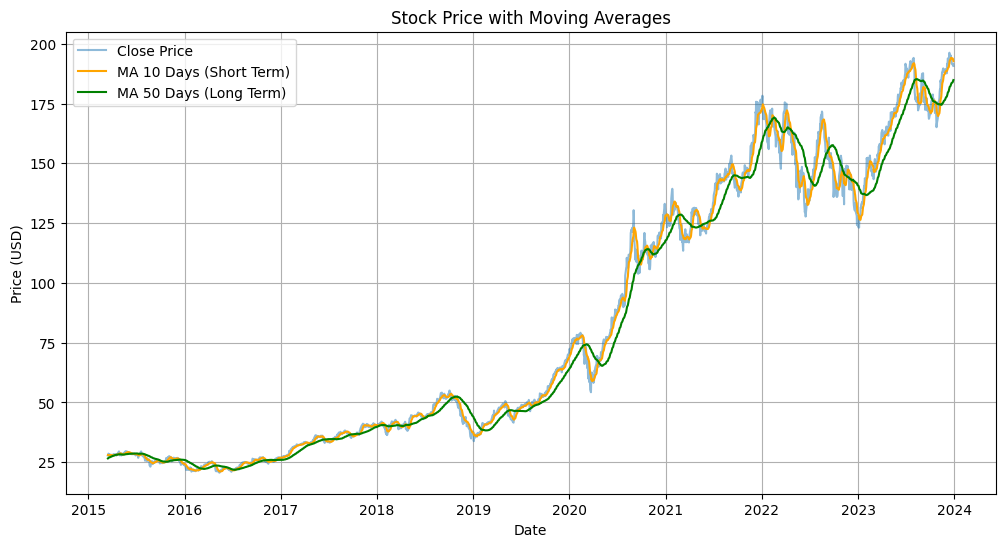

In [ ]:
# --- พล็อตกราฟดูเทรนด์ ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, df['MA_10'], label='MA 10 Days (Short Term)', color='orange')
plt.plot(df.index, df['MA_50'], label='MA 50 Days (Long Term)', color='green')
plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
# --- 1. สร้างโจทย์ให้ AI (Prepare Data) ---
# เราจะให้ AI ดูข้อมูล "วันนี้" (X) เพื่อทายราคา "พรุ่งนี้" (y)
# สร้างเฉลย: ขยับราคาปิดขึ้นมา 1 วัน (Prediction = ราคาของวันพรุ่งนี้)
df['Prediction'] = df['Close'].shift(-1)

In [ ]:
# ลบแถวสุดท้ายทิ้ง (เพราะวันสุดท้ายไม่มีราคาของ "พรุ่งนี้" ให้ทาย)
df.dropna(inplace=True)

In [ ]:
# กำหนดตัวแปร
# X = สิ่งที่ AI เห็น (ราคาปิดวันนี้, เส้น MA วันนี้, ราคาเมื่อวาน)
X = df[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Close_Lag1']]
# y = สิ่งที่ AI ต้องทาย (ราคาปิดพรุ่งนี้)
y = df['Prediction']

In [ ]:
# --- 2. แบ่งข้อมูลสอบ (Train/Test Split) ---
# ห้ามสุ่มมั่ว (Random Split) เพราะหุ้นเป็นเรื่องของเวลา
# เราจะใช้ข้อมูล 80% แรกสอน และ 20% หลังเอาไว้สอบ
split_index = int(len(df) * 0.8) # จุดตัดที่ 80%

X_train = X[:split_index] # ข้อมูลสอน (อดีต)
y_train = y[:split_index] # เฉลยของข้อมูลสอน

X_test = X[split_index:]  # ข้อมูลสอบ (ปัจจุบัน-อนาคต)
y_test = y[split_index:]  # เฉลยเอาไว้ตรวจคะแนน

In [ ]:
# --- 3. เริ่มสอน AI (Train Model) ---
print("🤖 กำลังฝึกสมอง AI... (อาจใช้เวลาสักครู่)")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train) # สั่งให้เรียน

🤖 กำลังฝึกสมอง AI... (อาจใช้เวลาสักครู่)


RandomForestRegressor(random_state=42)

In [ ]:
# --- 4. ลองสอบจริง (Prediction) ---
# ให้ AI ทายราคาของช่วง Test
predictions = model.predict(X_test)

In [ ]:
# คำนวณความแม่นยำ (RMSE - ยิ่งน้อยยิ่งดี)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"✅ ฝึกเสร็จแล้ว! ค่าความคลาดเคลื่อนเฉลี่ย (RMSE): {rmse:.2f} USD")

✅ ฝึกเสร็จแล้ว! ค่าความคลาดเคลื่อนเฉลี่ย (RMSE): 8.04 USD


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

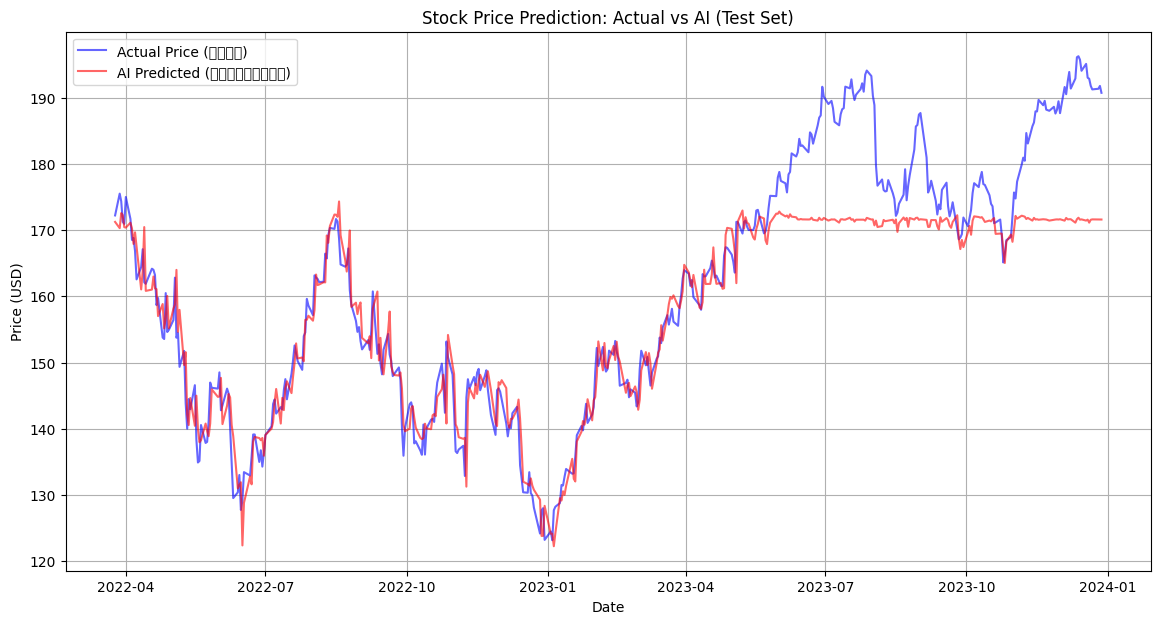

In [ ]:
# --- 5. ตรวจผลงาน (Visualization) ---
# พล็อตเทียบ ราคาจริง vs ราคาที่ AI ทาย
plt.figure(figsize=(14, 7))
plt.plot(df.index[split_index:], y_test, label='Actual Price (เฉลย)', color='blue', alpha=0.6)
plt.plot(df.index[split_index:], predictions, label='AI Predicted (ที่ทายได้)', color='red', alpha=0.6)
plt.title(f'Stock Price Prediction: Actual vs AI (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

📥 กำลังดึงข้อมูล AAPL...


/tmp/ipython-input-4238346285.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


✅ ได้ข้อมูลมาทั้งหมด 1006 วัน
🧹 ข้อมูลหลังทำความสะอาดเหลือ: 956 วัน
🤖 กำลังฝึกสมอง AI (Linear Regression)...
🎯 ฝึกเสร็จแล้ว! ความคลาดเคลื่อน (RMSE): 2.12 USD


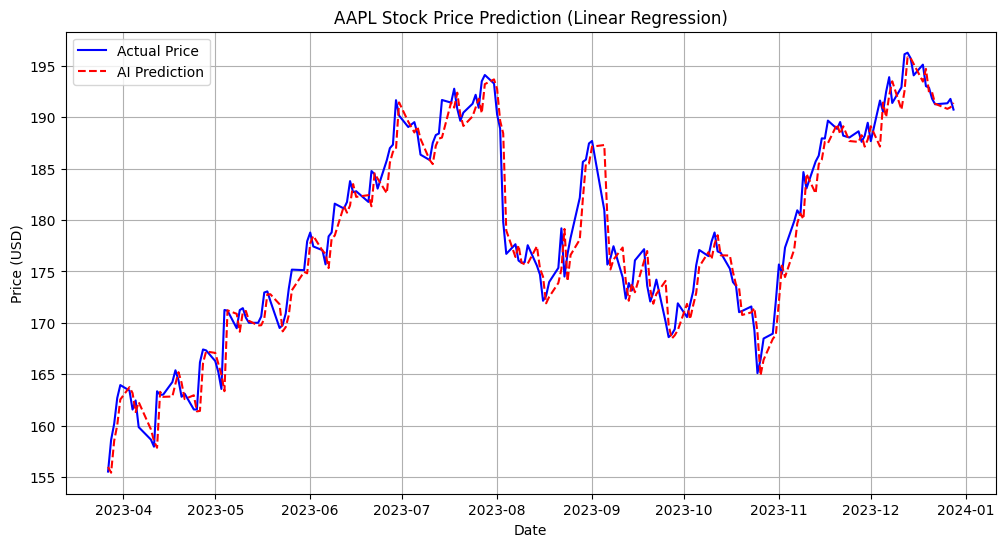

In [ ]:
# --- รวมทุกขั้นตอนไว้ในที่เดียว เพื่อป้องกันข้อมูลหาย ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. ดึงข้อมูลใหม่ (Data Collection)
ticker = 'AAPL'
print(f"📥 กำลังดึงข้อมูล {ticker}...")
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')

if len(df) == 0:
    print("❌ Error: ไม่พบข้อมูลหุ้น กรุณาเช็คชื่อหุ้นหรืออินเทอร์เน็ต")
else:
    print(f"✅ ได้ข้อมูลมาทั้งหมด {len(df)} วัน")

    # 2. ปรุงข้อมูล (Feature Engineering)
    # สร้างเส้นค่าเฉลี่ยและ Lag Feature
    df['MA_10'] = df['Close'].rolling(window=10).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    df['Daily_Return'] = df['Close'].pct_change()
    df['Close_Lag1'] = df['Close'].shift(1)

    # สร้างเฉลย (Prediction) คือราคาปิดของวันพรุ่งนี้
    df['Prediction'] = df['Close'].shift(-1)

    # 3. ลบค่าว่าง (Cleaning)
    # ลบแถวที่มี NaN (ช่วงแรกที่ไม่มี MA และวันสุดท้ายที่ไม่มีเฉลย)
    df_clean = df.dropna()

    print(f"🧹 ข้อมูลหลังทำความสะอาดเหลือ: {len(df_clean)} วัน")

    if len(df_clean) > 0:
        # 4. แบ่งข้อมูลสอน/สอบ (Split Data)
        X = df_clean[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Close_Lag1']]
        y = df_clean['Prediction']

        split = int(len(df_clean) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # 5. สอน AI (Training)
        print("🤖 กำลังฝึกสมอง AI (Linear Regression)...")
        model = LinearRegression()
        model.fit(X_train, y_train)

        # 6. วัดผล (Evaluation)
        predictions = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        print(f"🎯 ฝึกเสร็จแล้ว! ความคลาดเคลื่อน (RMSE): {rmse:.2f} USD")

        # 7. วาดกราฟโชว์ (Visualization)
        plt.figure(figsize=(12, 6))
        plt.plot(df_clean.index[split:], y_test, label='Actual Price', color='blue')
        plt.plot(df_clean.index[split:], predictions, label='AI Prediction', color='red', linestyle='--')
        plt.title(f'{ticker} Stock Price Prediction (Linear Regression)')
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("⚠️ ข้อมูลไม่เพียงพอสำหรับการเทรน (โดนลบจนหมด)")


🚀 กำลังเริ่มวิเคราะห์: AAPL
🎯 RMSE (AAPL): 2.12


/tmp/ipython-input-1008492633.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


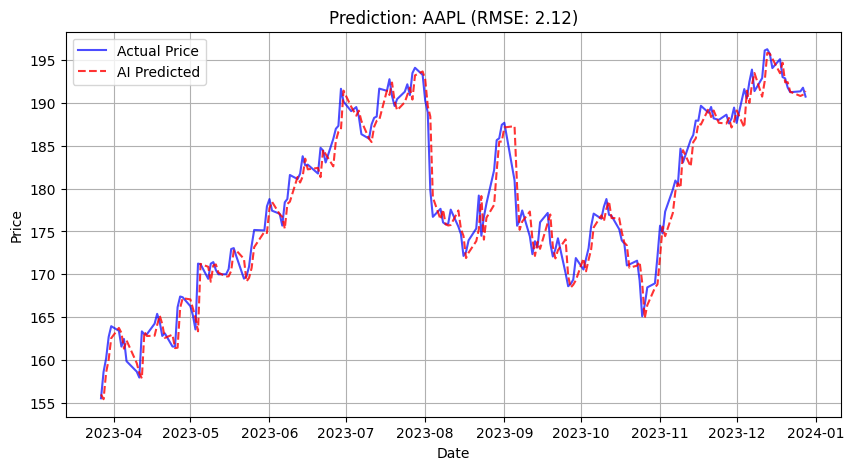


🚀 กำลังเริ่มวิเคราะห์: TSLA
🎯 RMSE (TSLA): 7.05


/tmp/ipython-input-1008492633.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


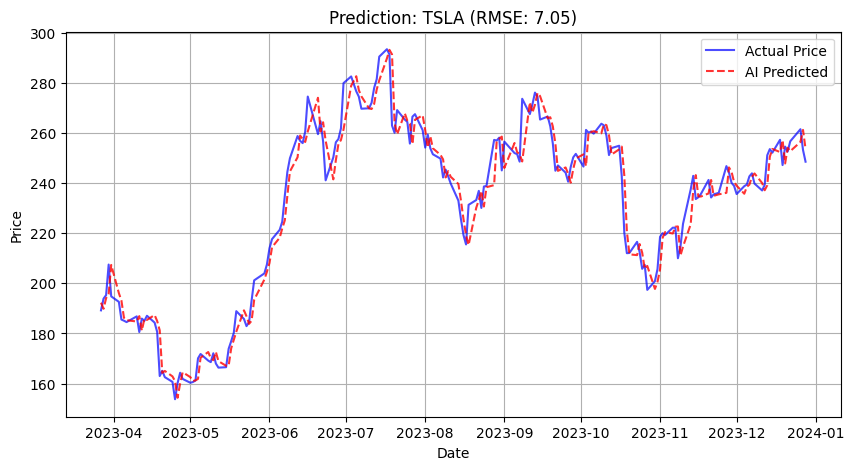


🚀 กำลังเริ่มวิเคราะห์: BTC-USD
🎯 RMSE (BTC-USD): 643.92


/tmp/ipython-input-1008492633.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


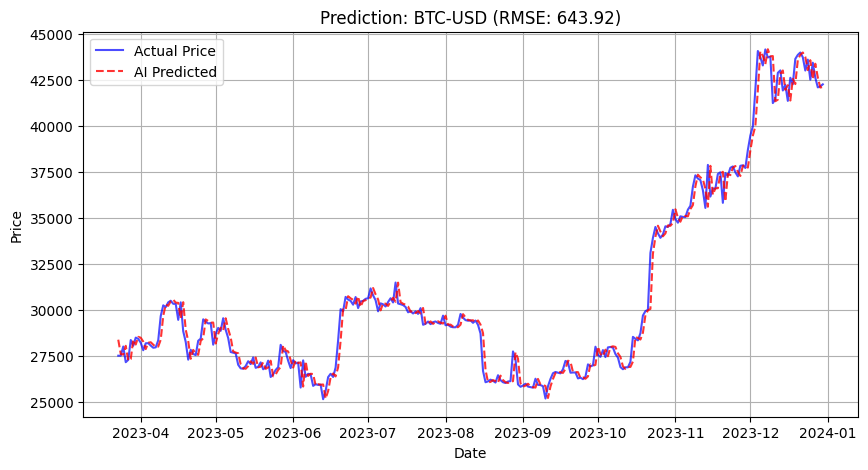


🚀 กำลังเริ่มวิเคราะห์: PTT.BK


/tmp/ipython-input-1008492633.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


🎯 RMSE (PTT.BK): 0.32


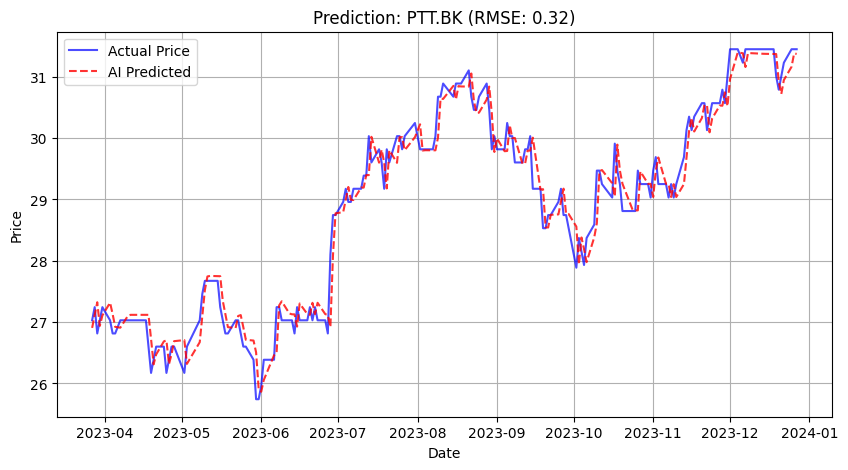

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- กำหนดรายชื่อหุ้นที่อยากทำนาย (เพิ่มลดตรงนี้ได้เลย) ---
# AAPL = Apple, TSLA = Tesla, BTC-USD = Bitcoin, PTT.BK = ปตท. (หุ้นไทย)
tickers_list = ['AAPL', 'TSLA', 'BTC-USD', 'PTT.BK']

for ticker in tickers_list:
    print(f"\n{'='*40}")
    print(f"🚀 กำลังเริ่มวิเคราะห์: {ticker}")
    print(f"{'='*40}")

    # 1. ดึงข้อมูล
    df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)

    if len(df) == 0:
        print(f"❌ ไม่พบข้อมูลสำหรับ {ticker}")
        continue

    # 2. ปรุงข้อมูล (Feature Engineering)
    # ใช้ .copy() เพื่อไม่ให้เตือน SettingWithCopyWarning
    df = df.copy()
    df['MA_10'] = df['Close'].rolling(window=10).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    df['Daily_Return'] = df['Close'].pct_change()
    df['Close_Lag1'] = df['Close'].shift(1)
    df['Prediction'] = df['Close'].shift(-1) # เฉลย (ราคาพรุ่งนี้)

    # 3. ลบค่าว่าง
    df_clean = df.dropna()

    if len(df_clean) > 100: # เช็คว่าข้อมูลเยอะพอไหม
        # 4. แบ่งข้อมูล
        X = df_clean[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Close_Lag1']]
        y = df_clean['Prediction']

        split = int(len(df_clean) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # 5. เทรนโมเดล
        model = LinearRegression()
        model.fit(X_train, y_train)

        # 6. วัดผล
        predictions = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        print(f"🎯 RMSE ({ticker}): {rmse:.2f}")

        # 7. พล็อตกราฟ (แยกทีละรูป)
        plt.figure(figsize=(10, 5))
        plt.plot(df_clean.index[split:], y_test, label='Actual Price', color='blue', alpha=0.7)
        plt.plot(df_clean.index[split:], predictions, label='AI Predicted', color='red', linestyle='--', alpha=0.8)
        plt.title(f'Prediction: {ticker} (RMSE: {rmse:.2f})')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.show() # โชว์กราฟทันที ก่อนวนไปตัวถัดไป

    else:
        print(f"⚠️ ข้อมูล {ticker} น้อยเกินไป ข้ามไปตัวถัดไป")